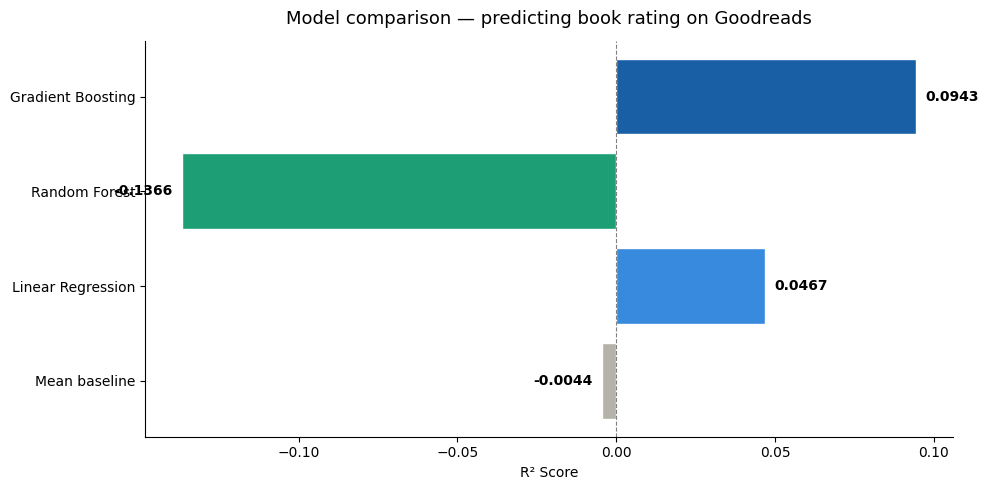

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# Load data
df = pd.read_csv('GOODREADS_dataset_cleaned.csv', encoding='utf-8')
df['series_number'] = df['series_number'].fillna(0)
for col in ['has_series_info', 'has_subtitle', 'has_middle_name']:
    df[col] = df[col].astype(int)
le1 = LabelEncoder()
le2 = LabelEncoder()
df['title_complexity_enc'] = le1.fit_transform(df['title_complexity'].astype(str))
df['title_type_enc'] = le2.fit_transform(df['title_type'].astype(str))

FEATURES = ['title_length','word_count','author_name_length','series_number',
            'has_series_info','has_subtitle','has_middle_name','author_book_count',
            'title_complexity_enc','title_type_enc']

X = df[FEATURES].values
y = df['rating'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

# Train all models
mean_pred = np.full_like(y_test, y_train.mean())
lr_pred = LinearRegression().fit(X_train_s, y_train).predict(X_test_s)
rf_pred = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1).fit(X_train, y_train).predict(X_test)
gb_pred = GradientBoostingRegressor(n_estimators=200, random_state=42).fit(X_train, y_train).predict(X_test)

results = {
    'Mean baseline': r2_score(y_test, mean_pred),
    'Linear Regression': r2_score(y_test, lr_pred),
    'Random Forest': r2_score(y_test, rf_pred),
    'Gradient Boosting': r2_score(y_test, gb_pred)
}

# Chart
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#B4B2A9','#378ADD','#1D9E75','#185FA5']
bars = ax.barh(list(results.keys()), list(results.values()), color=colors, edgecolor='white')
ax.axvline(0, color='gray', linewidth=0.8, linestyle='--')
ax.set_xlabel('R² Score')
ax.set_title('Model comparison — predicting book rating on Goodreads', fontsize=13, pad=12)

for bar, score in zip(bars, results.values()):
    width = bar.get_width()
    x = width + 0.003 if width >= 0 else width - 0.003
    ax.text(x, bar.get_y() + bar.get_height()/2, f'{score:.4f}',
            va='center', ha='left' if width >= 0 else 'right', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('ml_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

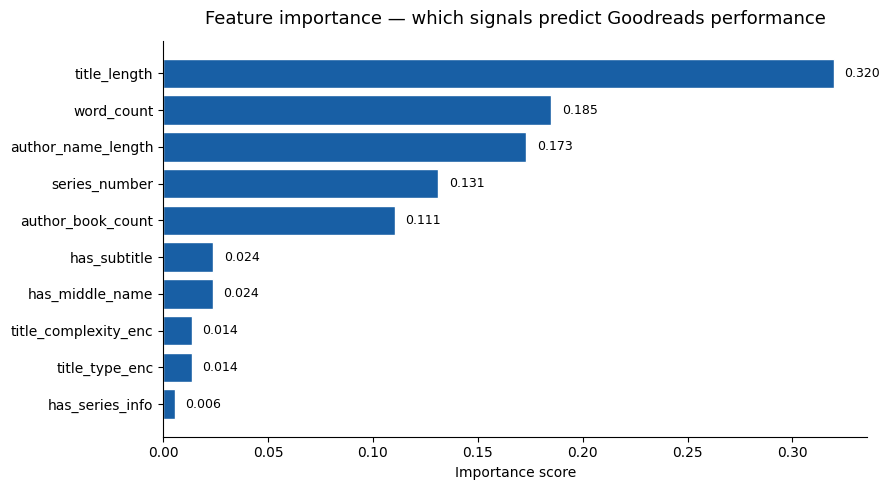

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import GradientBoostingRegressor
import warnings
warnings.filterwarnings('ignore')

# Load data
df = pd.read_csv('GOODREADS_dataset_cleaned.csv', encoding='utf-8')
df['series_number'] = df['series_number'].fillna(0)
for col in ['has_series_info', 'has_subtitle', 'has_middle_name']:
    df[col] = df[col].astype(int)
le1 = LabelEncoder()
le2 = LabelEncoder()
df['title_complexity_enc'] = le1.fit_transform(df['title_complexity'].astype(str))
df['title_type_enc'] = le2.fit_transform(df['title_type'].astype(str))

FEATURES = ['title_length', 'word_count', 'author_name_length', 'series_number',
            'has_series_info', 'has_subtitle', 'has_middle_name', 'author_book_count',
            'title_complexity_enc', 'title_type_enc']

X = df[FEATURES].values
y = df['rating'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

gb = GradientBoostingRegressor(n_estimators=200, random_state=42).fit(X_train, y_train)

# Chart
fig, ax = plt.subplots(figsize=(9, 5))

fi = pd.Series(gb.feature_importances_, index=FEATURES).sort_values()

bars = ax.barh(fi.index, fi.values, color='#185FA5', edgecolor='white')
ax.set_xlabel('Importance score')
ax.set_title('Feature importance — which signals predict Goodreads performance', fontsize=13, pad=12)

for bar, val in zip(bars, fi.values):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('ml_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()